| **Variável** | **Descrição** | **Exemplo** |
| :--- | :--- | :--- |
| age | idade do cliente, em anos | 30 |
| job | profissão do cliente | self-employed |
| maritial | estado civil do cliente | married |
| education | habilitações literárias do cliente | primary |
| default | se o cliente tem crédito em incumprimento | yes |
| balance | saldo médio anual da conta, em euros | 1350 |
| housing | se o cliente tem crédito à habitação | yes |
| loan | se o cliente tem crédito pessoal | no |
| contact | tipo de comunicação | cellular |
| day | dia do mês do último contacto | 16 |
| month | mês do último contacto | feb |
| duration | duração da última chamada, em segundos | 220 |
| campaign | número de contactos durante a campanha | 1 |
| pdays | número de dias desde o último contacto (-1 se nunca) | 330 |
| previous | número total de contactos antes da campanha | 4 |
| poutcome | resultado da última campanha | failure |
| y | se o cliente subscreveu um depósito a prazo | no |

#### <span style="color:#white; font-weight:bold;"> *Setup* </span> ⚙️

In [1]:
# Setup
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)


In [3]:
# Configuration
RANDOM_SEED = 42
DATA_PATH = "data.csv" 
TARGET_COL = "y"
ID_COL = None  # Example: "client_id"
CSV_SEPARATOR = ";"  # Change to "," if needed
TEST_SIZE = 0.25

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

In [ ]:
# load the data
try:
    df = pd.read_csv("data.csv", sep=";")
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: File not found.")

# print the first 3 rows
df.head(3)

Loading data...
Data loaded successfully.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


In [12]:

for col in df.select_dtypes(include=["object"]).columns:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n")

Column: job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


Column: marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


Column: education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


Column: default
default
no     44396
yes      815
Name: count, dtype: int64


Column: housing
housing
yes    25130
no     20081
Name: count, dtype: int64


Column: loan
loan
no     37967
yes     7244
Name: count, dtype: int64


Column: contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


Column: month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan   

In [4]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")


numeric_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns



print("\nNumeric descriptive statistics:")
numeric_summary = df[numeric_cols].agg(
    ["count", "mean", "std", "min", "median", "max"]
).T

display(numeric_summary)


print("\nCategorical descriptive statistics:")

categorical_summary = pd.DataFrame({
    "count": df[categorical_cols].count(),
    "unique": df[categorical_cols].nunique(),
    "top": df[categorical_cols].mode().iloc[0],
    "freq": df[categorical_cols].apply(lambda x: x.value_counts().iloc[0] if not x.value_counts().empty else None)
})

display(categorical_summary)


Duplicate rows: 0

Numeric descriptive statistics:


,count,mean,std,min,median,max
age,45211.0,40.936210,10.618762,18.0,39.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,448.0,102127.0
day,45211.0,15.806419,8.322476,1.0,16.0,31.0
duration,45211.0,258.163080,257.527812,0.0,180.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,2.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,275.0



Categorical descriptive statistics:


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


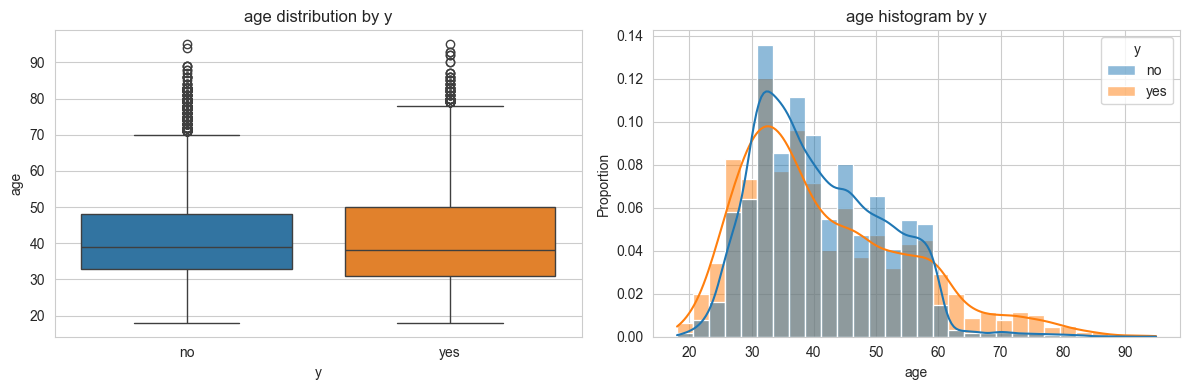

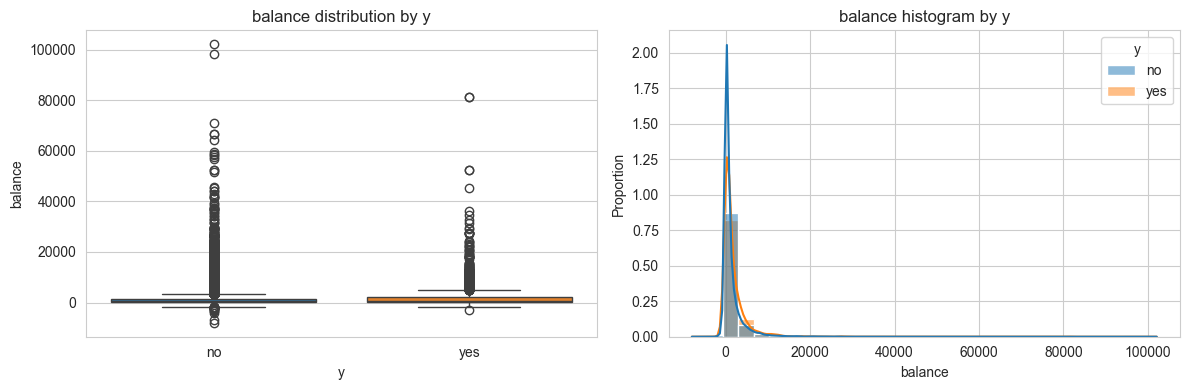

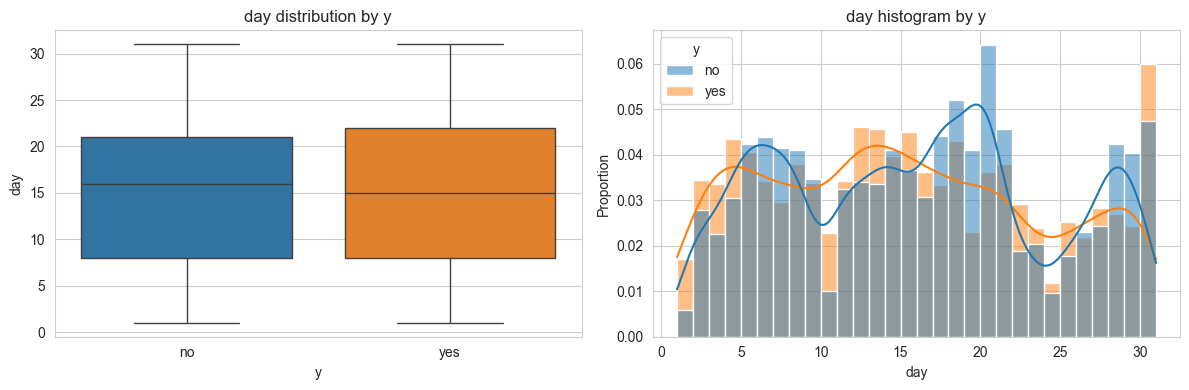

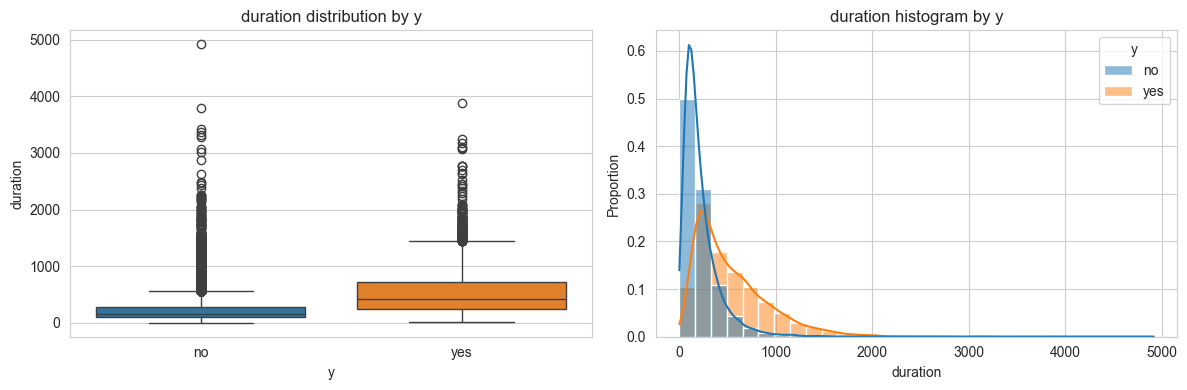

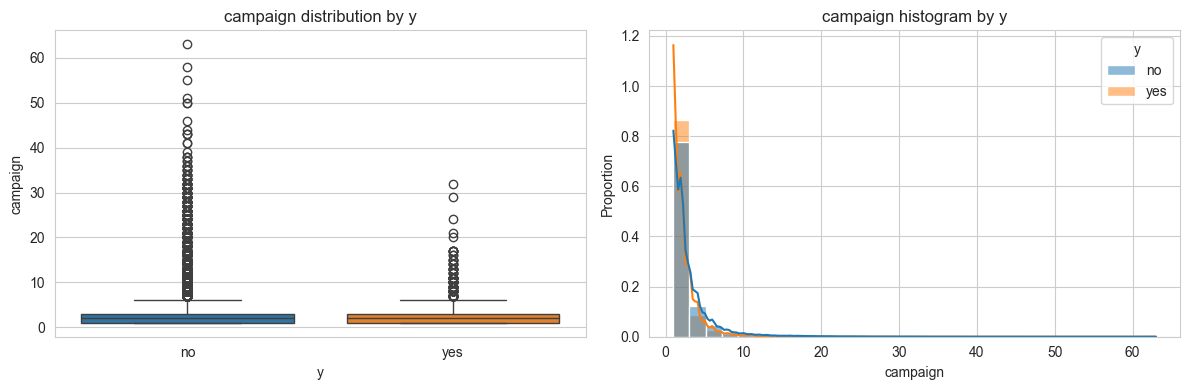

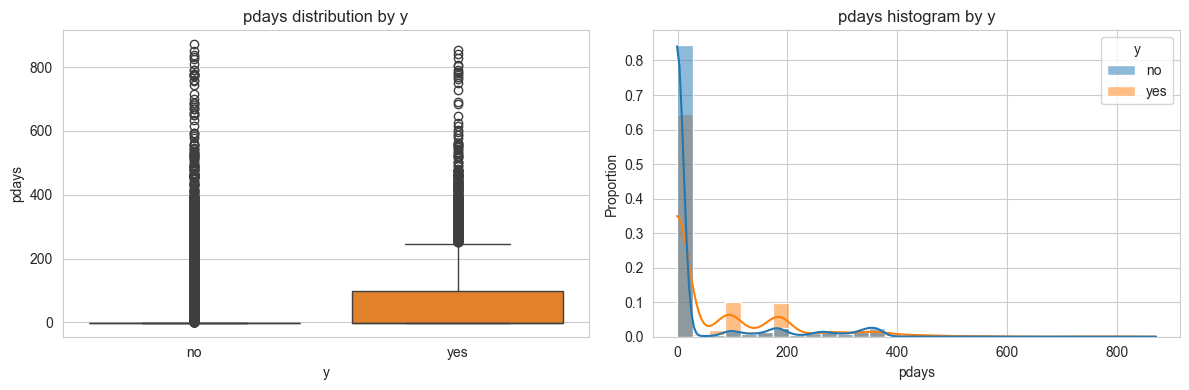

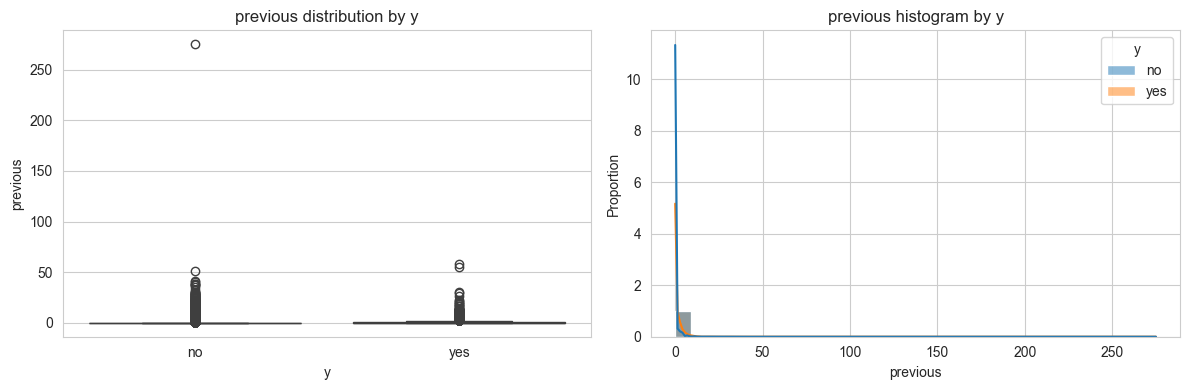

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=["number"]).columns

# Remove target if numeric
numeric_cols = [col for col in numeric_cols if col != TARGET_COL]

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Boxplot
    sns.boxplot(
        data=df,
        x=TARGET_COL,
        y=col,
        hue=TARGET_COL,
        dodge=False,
        legend=False,
        ax=axes[0]
    )
    axes[0].set_title(f"{col} distribution by {TARGET_COL}")

    # Histogram with proportions per class
    sns.histplot(
        data=df,
        x=col,
        hue=TARGET_COL,
        stat="probability",      # proportions instead of counts
        common_norm=False,       # normalize each class separately
        kde=True,              # add KDE curve
        bins=30,
        ax=axes[1]
    )
    axes[1].set_title(f"{col} histogram by {TARGET_COL}")
    axes[1].set_ylabel("Proportion")

    plt.tight_layout()
    plt.show()

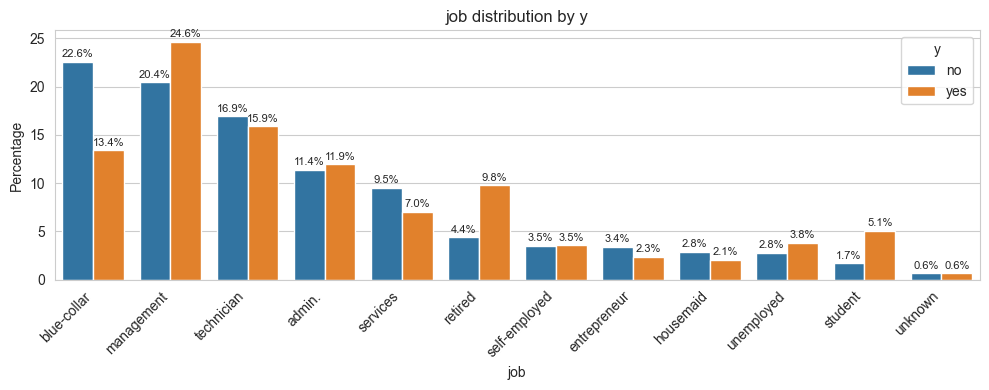

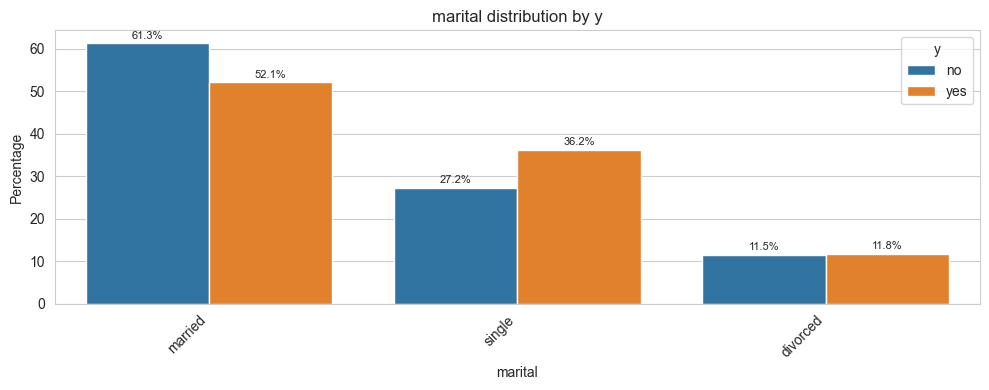

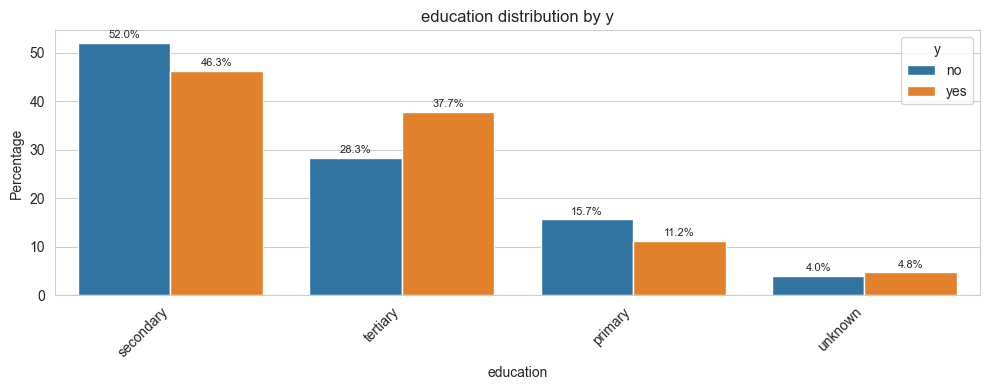

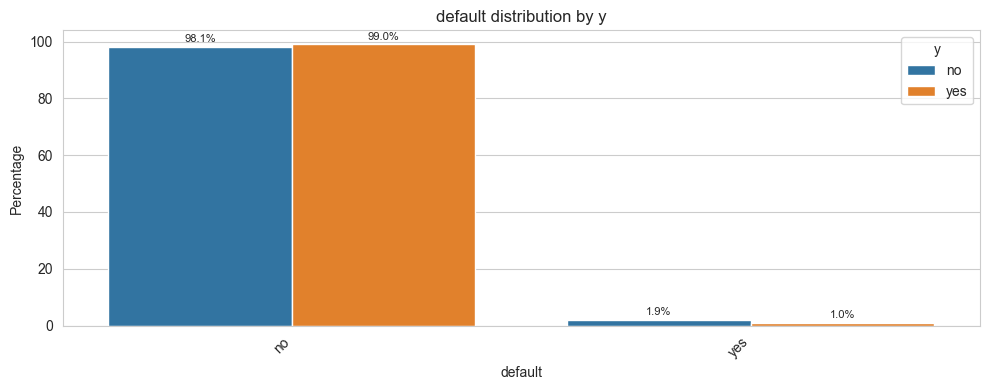

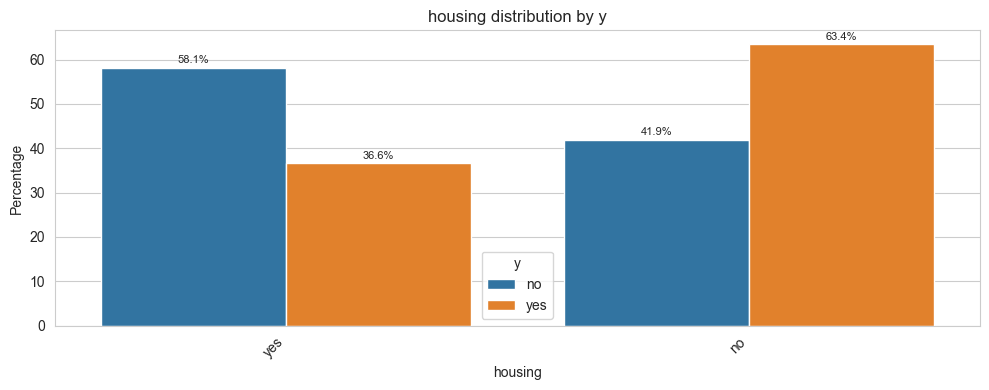

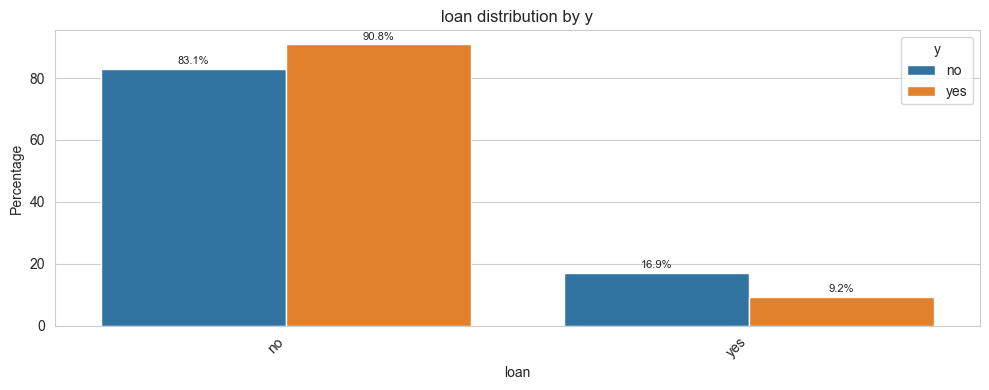

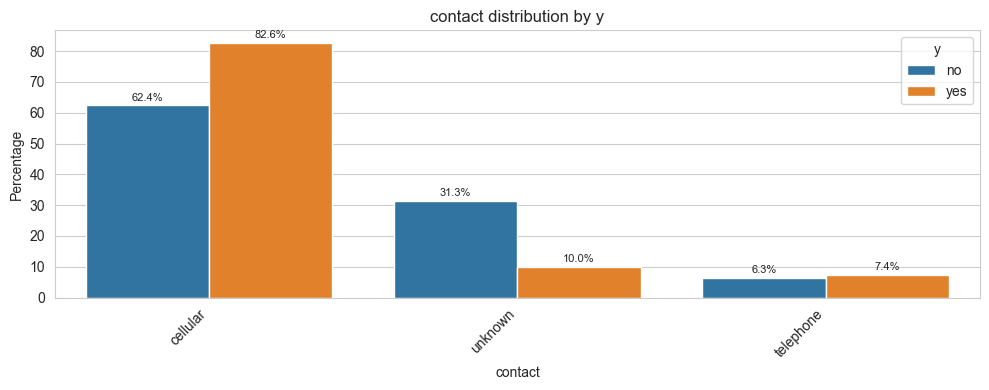

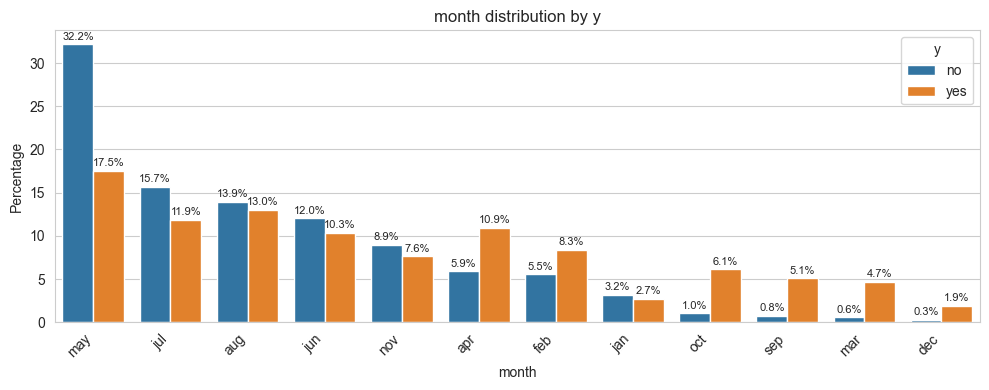

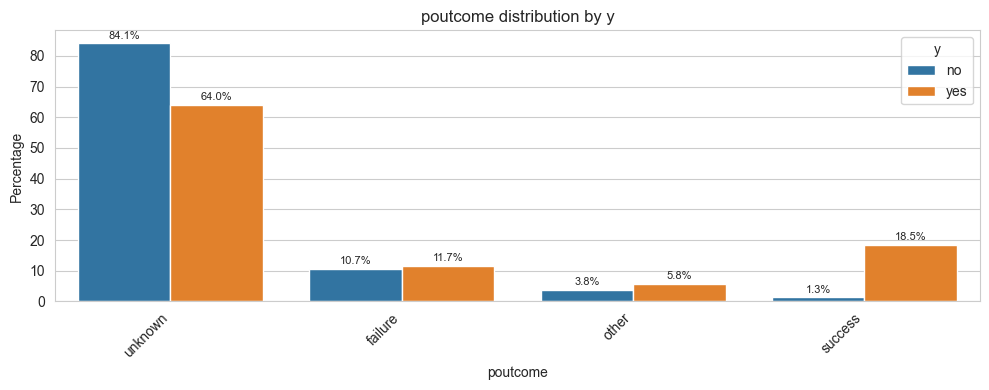

In [11]:


categorical_cols = df.select_dtypes(include=["object", "category"]).columns
categorical_cols = [col for col in categorical_cols if col != TARGET_COL]

for col in categorical_cols:
    plot_df = (
        df.groupby(TARGET_COL)[col]
        .value_counts(normalize=True)
        .rename("percentage")
        .mul(100)
        .reset_index()
    )

    plt.figure(figsize=(10, 4))

    ax = sns.barplot(
        data=plot_df,
        x=col,
        y="percentage",
        hue=TARGET_COL
    )

    # Add % labels on top of each bar
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            label_type="edge",
            padding=2,
            fontsize=8
        )

    plt.title(f"{col} distribution by {TARGET_COL}")
    plt.ylabel("Percentage")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()